# Study of Short-Horizon Equity Return Dynamics

## Problem Setup

### Goal:

Test whether simple lagged-return features contain any weak predictive signal
for next-day returns.

The notebook uses basic linear models and chronological splits to avoid
look-ahead bias. The goal is exploration, not building a trading strategy.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## Data Collection and Preprocessing

Download and clean AAPL daily data.

In [2]:
data = yf.download("AAPL", start="2015-01-01")
print(len(data))
data.head()




[*********************100%***********************]  1 of 1 completed

2859


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [3]:
# reset index
data = data.reset_index()
data = data.drop(columns=["index", "level_0"], errors="ignore")

data.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
1,2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2,2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
3,2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [4]:
# flatten column names if needed
data.columns = data.columns.get_level_values(0)

data.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
1,2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2,2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
3,2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [5]:
# sort by date
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)

data.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
1,2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2,2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
3,2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [6]:
# check date range
data["Date"].min(), data["Date"].max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2026-05-15 00:00:00'))

## Preliminary Data Inspection

In [7]:
# dataset overview
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2859 non-null   datetime64[ns]
 1   Close   2859 non-null   float64       
 2   High    2859 non-null   float64       
 3   Low     2859 non-null   float64       
 4   Open    2859 non-null   float64       
 5   Volume  2859 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 134.1 KB


In [8]:
# missing values
data.isna().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Exploratory Data Analysis

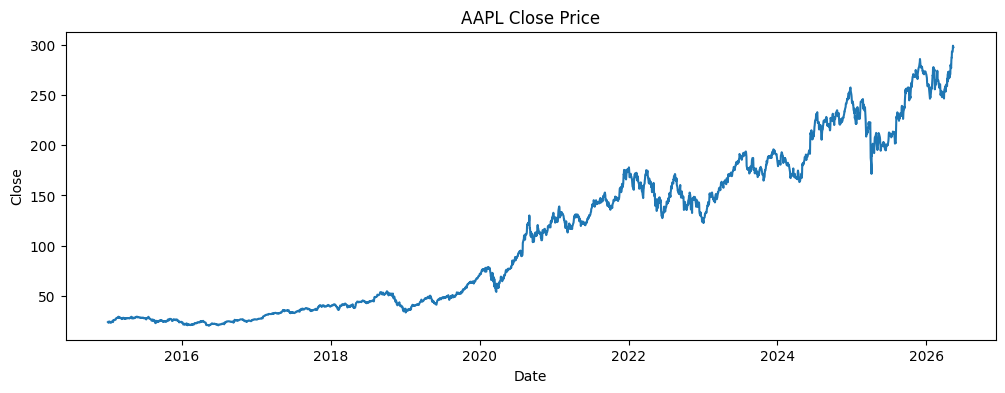

In [9]:
# Plot the closing price over time to visualize the overall price evolution
plt.figure(figsize=(12, 4))
plt.plot(data["Date"], data["Close"])
plt.title("AAPL Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.show()

In [10]:
# daily returns
data["ret"] = data["Close"].pct_change()



In [11]:
#  first rows (returns)
data[["Date", "Close", "ret"]].head(10)

Price,Date,Close,ret
0,2015-01-02,24.192602,NaN
1,2015-01-05,23.511057,-0.028172
2,2015-01-06,23.513268,0.000094
3,2015-01-07,23.842981,0.014022
4,2015-01-08,24.759081,0.038422
5,2015-01-09,24.785633,0.001072
6,2015-01-12,24.174906,-0.024640
7,2015-01-13,24.389540,0.008878
8,2015-01-14,24.296610,-0.003810
9,2015-01-15,23.637190,-0.027140


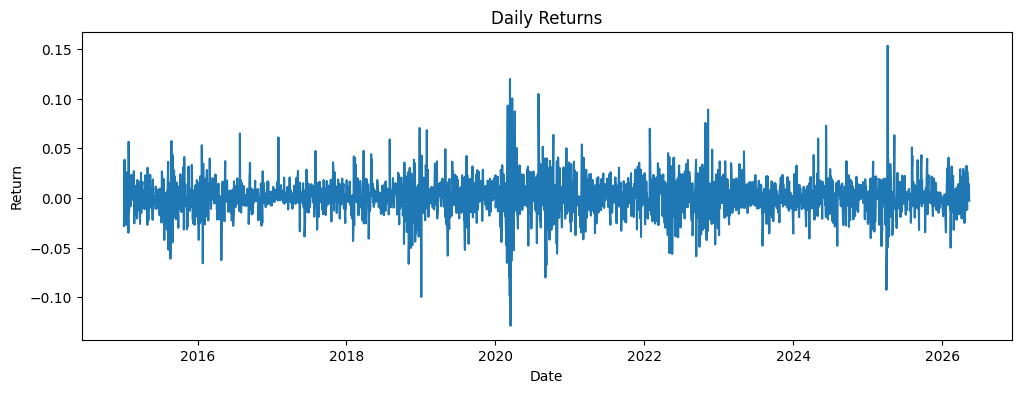

In [12]:
# returns over time
plt.figure(figsize=(12, 4))
plt.plot(data["Date"], data["ret"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

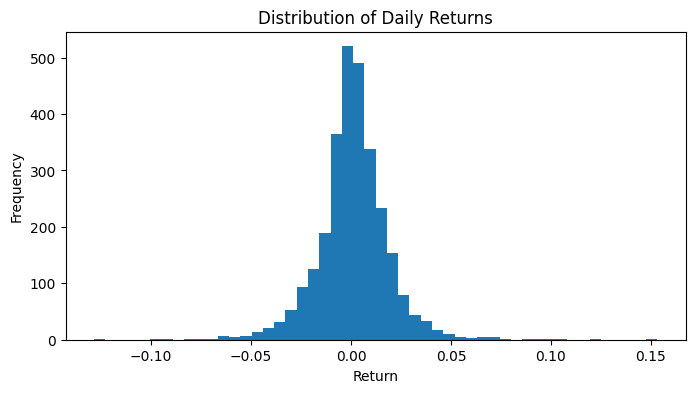

In [13]:
# return distribution
plt.figure(figsize=(8, 4))
plt.hist(data["ret"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.show()

## Feature Engineering

### Rolling Mean Feature

In [14]:
# 5d rolling mean
data["rolling_mean_5"] = data["ret"].rolling(5).mean()

data[["Date", "ret", "rolling_mean_5"]].head(10)

Price,Date,ret,rolling_mean_5
0,2015-01-02,NaN,NaN
1,2015-01-05,-0.028172,NaN
2,2015-01-06,0.000094,NaN
3,2015-01-07,0.014022,NaN
4,2015-01-08,0.038422,NaN
5,2015-01-09,0.001072,0.005088
6,2015-01-12,-0.024640,0.005794
7,2015-01-13,0.008878,0.007551
8,2015-01-14,-0.003810,0.003984
9,2015-01-15,-0.027140,-0.009128


### Lagged Return Features

In [15]:
# lagged returns
data["lag1"] = data["ret"].shift(1)
data["lag2"] = data["ret"].shift(2)
data["lag3"] = data["ret"].shift(3)

data[["Date", "ret", "lag1", "lag2", "lag3"]].head(10)

Price,Date,ret,lag1,lag2,lag3
0,2015-01-02,NaN,NaN,NaN,NaN
1,2015-01-05,-0.028172,NaN,NaN,NaN
2,2015-01-06,0.000094,-0.028172,NaN,NaN
3,2015-01-07,0.014022,0.000094,-0.028172,NaN
4,2015-01-08,0.038422,0.014022,0.000094,-0.028172
5,2015-01-09,0.001072,0.038422,0.014022,0.000094
6,2015-01-12,-0.024640,0.001072,0.038422,0.014022
7,2015-01-13,0.008878,-0.024640,0.001072,0.038422
8,2015-01-14,-0.003810,0.008878,-0.024640,0.001072
9,2015-01-15,-0.027140,-0.003810,0.008878,-0.024640


### Rolling Volatility Feature

In [16]:
# 20d rolling volatility
data["rolling_std_20"] = data["ret"].rolling(20).std()

data[["Date", "ret", "rolling_std_20"]].head(25)

Price,Date,ret,rolling_std_20
0,2015-01-02,NaN,NaN
1,2015-01-05,-0.028172,NaN
2,2015-01-06,0.000094,NaN
3,2015-01-07,0.014022,NaN
4,2015-01-08,0.038422,NaN
5,2015-01-09,0.001072,NaN
6,2015-01-12,-0.024640,NaN
7,2015-01-13,0.008878,NaN
8,2015-01-14,-0.003810,NaN
9,2015-01-15,-0.027140,NaN


### Prediction Target
The prediction target is defined as the next-day return.

In [17]:
# next-day target
data["target"] = data["ret"].shift(-1)

data[["Date", "ret", "lag1", "lag2", "lag3", "rolling_std_20", "target"]].head(25)

Price,Date,ret,lag1,lag2,lag3,rolling_std_20,target
0,2015-01-02,NaN,NaN,NaN,NaN,NaN,-0.028172
1,2015-01-05,-0.028172,NaN,NaN,NaN,NaN,0.000094
2,2015-01-06,0.000094,-0.028172,NaN,NaN,NaN,0.014022
3,2015-01-07,0.014022,0.000094,-0.028172,NaN,NaN,0.038422
4,2015-01-08,0.038422,0.014022,0.000094,-0.028172,NaN,0.001072
5,2015-01-09,0.001072,0.038422,0.014022,0.000094,NaN,-0.024640
6,2015-01-12,-0.024640,0.001072,0.038422,0.014022,NaN,0.008878
7,2015-01-13,0.008878,-0.024640,0.001072,0.038422,NaN,-0.003810
8,2015-01-14,-0.003810,0.008878,-0.024640,0.001072,NaN,-0.027140
9,2015-01-15,-0.027140,-0.003810,0.008878,-0.024640,NaN,-0.007770


In [18]:
# missing values after feature creation
data.isna().sum()

Price
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
ret                1
rolling_mean_5     5
lag1               2
lag2               3
lag3               4
rolling_std_20    20
target             1
dtype: int64

In [19]:
# drop missing values
data = data.dropna().reset_index(drop=True)

data.head()

Price,Date,Close,High,Low,Open,Volume,ret,rolling_mean_5,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,26.250513,26.370005,25.686249,26.122172,250956400,0.012547,0.010113,-0.014634,0.031133,0.056533,0.023813,0.000169
1,2015-02-03,26.254938,26.352300,26.024806,26.221746,207662800,0.000169,0.017150,0.012547,-0.014634,0.031133,0.022587,0.007670
2,2015-02-04,26.456305,26.666522,26.179704,26.221748,280598800,0.007670,0.007377,0.000169,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,26.645138,26.709563,26.491851,26.662909,168984800,0.007138,0.002578,0.007670,0.000169,0.012547,0.022477,-0.008421
4,2015-02-06,26.420759,26.714002,26.314125,26.662906,174826400,-0.008421,0.003820,0.007138,0.007670,0.000169,0.021310,0.006642


In [20]:
# modeling dataset
data[["Date", "ret", "lag1", "lag2", "lag3", "rolling_std_20", "target"]].head(10)

Price,Date,ret,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,0.012547,-0.014634,0.031133,0.056533,0.023813,0.000169
1,2015-02-03,0.000169,0.012547,-0.014634,0.031133,0.022587,0.007670
2,2015-02-04,0.007670,0.000169,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,0.007138,0.007670,0.000169,0.012547,0.022477,-0.008421
4,2015-02-06,-0.008421,0.007138,0.007670,0.000169,0.021310,0.006642
5,2015-02-09,0.006642,-0.008421,0.007138,0.007670,0.021313,0.019211
6,2015-02-10,0.019211,0.006642,-0.008421,0.007138,0.020479,0.023439
7,2015-02-11,0.023439,0.019211,0.006642,-0.008421,0.020844,0.012652
8,2015-02-12,0.012652,0.023439,0.019211,0.006642,0.020733,0.004903
9,2015-02-13,0.004903,0.012652,0.023439,0.019211,0.019089,0.005902


In [21]:
# final shape
print(data.shape)

(2838, 13)


In [22]:
# final NA check
data.isna().sum()

Price
Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
ret               0
rolling_mean_5    0
lag1              0
lag2              0
lag3              0
rolling_std_20    0
target            0
dtype: int64

### Missing Value Handling
Missing Values
Drop rows created by lags, rolling windows, and the shifted target.

In [23]:
# drop rows with missing values
data = data.dropna().reset_index(drop=True)

data.head()

Price,Date,Close,High,Low,Open,Volume,ret,rolling_mean_5,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,26.250513,26.370005,25.686249,26.122172,250956400,0.012547,0.010113,-0.014634,0.031133,0.056533,0.023813,0.000169
1,2015-02-03,26.254938,26.352300,26.024806,26.221746,207662800,0.000169,0.017150,0.012547,-0.014634,0.031133,0.022587,0.007670
2,2015-02-04,26.456305,26.666522,26.179704,26.221748,280598800,0.007670,0.007377,0.000169,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,26.645138,26.709563,26.491851,26.662909,168984800,0.007138,0.002578,0.007670,0.000169,0.012547,0.022477,-0.008421
4,2015-02-06,26.420759,26.714002,26.314125,26.662906,174826400,-0.008421,0.003820,0.007138,0.007670,0.000169,0.021310,0.006642


In [24]:
# final modeling columns
data[["Date", "ret", "lag1", "lag2", "lag3", "rolling_std_20", "target"]].head(10)

Price,Date,ret,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,0.012547,-0.014634,0.031133,0.056533,0.023813,0.000169
1,2015-02-03,0.000169,0.012547,-0.014634,0.031133,0.022587,0.007670
2,2015-02-04,0.007670,0.000169,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,0.007138,0.007670,0.000169,0.012547,0.022477,-0.008421
4,2015-02-06,-0.008421,0.007138,0.007670,0.000169,0.021310,0.006642
5,2015-02-09,0.006642,-0.008421,0.007138,0.007670,0.021313,0.019211
6,2015-02-10,0.019211,0.006642,-0.008421,0.007138,0.020479,0.023439
7,2015-02-11,0.023439,0.019211,0.006642,-0.008421,0.020844,0.012652
8,2015-02-12,0.012652,0.023439,0.019211,0.006642,0.020733,0.004903
9,2015-02-13,0.004903,0.012652,0.023439,0.019211,0.019089,0.005902


# Predictive Modeling
Use lag features and rolling volatility to predict next-day returns.

In [25]:
# feature matrix and target
features = ["lag1", "lag2", "lag3", "rolling_std_20"]

X = data[features]
y = data["target"]

print(X.shape)
print(y.shape)

(2838, 4)
(2838,)


### Chronological Train-Test Split

In [26]:
# chronological split
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2270, 4)
X_test : (568, 4)
y_train: (2270,)
y_test : (568,)


### Baseline Linear Models

In [27]:
# linear models
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [28]:
def safe_corr(pred, y):
    if np.std(pred) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(pred, y)[0, 1]

In [29]:
# OLS model
model_ols = LinearRegression()

model_ols.fit(X_train, y_train)

pred_ols = model_ols.predict(X_test)

In [30]:
# OLS correlation
corr_ols = np.corrcoef(pred_ols, y_test)[0, 1]

print("OLS correlation:", corr_ols)

OLS correlation: 0.06602410135042007


In [31]:
# ridge regression
model_ridge = Ridge(alpha=1.0)

model_ridge.fit(X_train, y_train)

pred_ridge = model_ridge.predict(X_test)

### Model Comparison

In [32]:
# ridge correlation
corr_ridge = np.corrcoef(pred_ridge, y_test)[0, 1]

print("Ridge correlation:", corr_ridge)

Ridge correlation: 0.07231550883572507


In [33]:
# lasso regression
model_lasso = Lasso(alpha=0.001)

model_lasso.fit(X_train, y_train)

pred_lasso = model_lasso.predict(X_test)

In [34]:
# lasso correlation
if np.std(pred_lasso) < 1e-10:
    corr_lasso = 0.0
    print("Lasso correlation: undefined (near-constant predictions)")
else:
    corr_lasso = safe_corr(pred_lasso, y_test)
    print("Lasso correlation:", corr_lasso)

Lasso correlation: undefined (near-constant predictions)


In [35]:
# model summary
results_models = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "Correlation": [corr_ols, corr_ridge, corr_lasso]
})

results_models

,Model,Correlation
0,OLS,0.066024
1,Ridge,0.072316
2,Lasso,0.000000


### Lag Structure Analysis

Check whether adding more lag features changes the out-of-sample correlation.

In [36]:
# ridge with lag1 only
features_lag1 = ["lag1"]

X1 = data[features_lag1]
y1 = data["target"]

X1_train = X1.iloc[:split_index]
X1_test = X1.iloc[split_index:]

y1_train = y1.iloc[:split_index]
y1_test = y1.iloc[split_index:]

model_lag1 = Ridge(alpha=1.0)

model_lag1.fit(X1_train, y1_train)

pred_lag1 = model_lag1.predict(X1_test)

corr_lag1 = np.corrcoef(pred_lag1, y1_test)[0, 1]

print("Ridge with lag1:", corr_lag1)

Ridge with lag1: -0.06356940866121832


In [37]:
# ridge with lag1 + lag2
features_lag12 = ["lag1", "lag2"]

X12 = data[features_lag12]
y12 = data["target"]

X12_train = X12.iloc[:split_index]
X12_test = X12.iloc[split_index:]

y12_train = y12.iloc[:split_index]
y12_test = y12.iloc[split_index:]

model_lag12 = Ridge(alpha=1.0)

model_lag12.fit(X12_train, y12_train)

pred_lag12 = model_lag12.predict(X12_test)

corr_lag12 = np.corrcoef(pred_lag12, y12_test)[0, 1]

print("Ridge with lag1 + lag2:", corr_lag12)

Ridge with lag1 + lag2: 0.04665519408776412


In [38]:
# ridge with lag1 + lag2 + lag3
features_lag123 = ["lag1", "lag2", "lag3"]

X123 = data[features_lag123]
y123 = data["target"]

X123_train = X123.iloc[:split_index]
X123_test = X123.iloc[split_index:]

y123_train = y123.iloc[:split_index]
y123_test = y123.iloc[split_index:]

model_lag123 = Ridge(alpha=1.0)

model_lag123.fit(X123_train, y123_train)

pred_lag123 = model_lag123.predict(X123_test)

corr_lag123 = np.corrcoef(pred_lag123, y123_test)[0, 1]

print("Ridge with lag1 + lag2 + lag3:", corr_lag123)

Ridge with lag1 + lag2 + lag3: 0.0735158609881146


In [39]:
# compare lag structures
results_lags = pd.DataFrame({
    "Feature_Set": ["lag1", "lag1 + lag2", "lag1 + lag2 + lag3"],
    "Correlation": [corr_lag1, corr_lag12, corr_lag123]
})

results_lags

,Feature_Set,Correlation
0,lag1,-0.063569
1,lag1 + lag2,0.046655
2,lag1 + lag2 + lag3,0.073516


## Volatility Feature Impact

We compare:
- lagged return features only
- lagged returns + rolling volatility

Goal: Evaluate whether volatility information improves predictive performance.

In [40]:
# compare lag features vs lag features + volatility
features_lags_only = ["lag1", "lag2", "lag3"]
features_lags_vol = ["lag1", "lag2", "lag3", "rolling_std_20"]

# lags only
X_lags = data[features_lags_only]
y_lags = data["target"]

X_lags_train = X_lags.iloc[:split_index]
X_lags_test = X_lags.iloc[split_index:]

y_lags_train = y_lags.iloc[:split_index]
y_lags_test = y_lags.iloc[split_index:]

model_lags = Ridge(alpha=1.0)

model_lags.fit(X_lags_train, y_lags_train)

pred_lags = model_lags.predict(X_lags_test)

corr_lags = np.corrcoef(pred_lags, y_lags_test)[0, 1]

# lags + volatility
X_lags_vol = data[features_lags_vol]
y_lags_vol = data["target"]

X_lags_vol_train = X_lags_vol.iloc[:split_index]
X_lags_vol_test = X_lags_vol.iloc[split_index:]

y_lags_vol_train = y_lags_vol.iloc[:split_index]
y_lags_vol_test = y_lags_vol.iloc[split_index:]

model_lags_vol = Ridge(alpha=1.0)

model_lags_vol.fit(X_lags_vol_train, y_lags_vol_train)

pred_lags_vol = model_lags_vol.predict(X_lags_vol_test)

corr_lags_vol = np.corrcoef(pred_lags_vol, y_lags_vol_test)[0, 1]

print("Ridge with lag features only     :", corr_lags)
print("Ridge with lag features + volatility:", corr_lags_vol)

Ridge with lag features only     : 0.0735158609881146
Ridge with lag features + volatility: 0.07231550883572507


In [41]:
# Summarize the impact of adding rolling volatility to the lag-based model
results_volatility = pd.DataFrame({
    "Feature_Set": ["lag1 + lag2 + lag3", "lag1 + lag2 + lag3 + rolling_std_20"],
    "Correlation": [corr_lags, corr_lags_vol]
})

results_volatility

,Feature_Set,Correlation
0,lag1 + lag2 + lag3,0.073516
1,lag1 + lag2 + lag3 + rolling_std_20,0.072316


In [42]:
# quick summary
print("Model comparison")
print(results_models)
print()

print("Lag structure comparison")
print(results_lags)
print()

print("Volatility feature impact")
print(results_volatility)

Model comparison
   Model  Correlation
0    OLS     0.066024
1  Ridge     0.072316
2  Lasso     0.000000

Lag structure comparison
          Feature_Set  Correlation
0                lag1    -0.063569
1         lag1 + lag2     0.046655
2  lag1 + lag2 + lag3     0.073516

Volatility feature impact
                           Feature_Set  Correlation
0                   lag1 + lag2 + lag3     0.073516
1  lag1 + lag2 + lag3 + rolling_std_20     0.072316


## Walk-Forward Validation

The model is evaluated through expanding training windows and yearly out-of-sample test periods to assess signal stability over time.

In [43]:
# walk-forward features
features_wf = ["lag1", "lag2", "lag3", "rolling_std_20"]

X_wf = data[features_wf]
y_wf = data["target"]
dates_wf = data["Date"]

In [44]:
# yearly test windows
walk_forward_windows = [
    ("2018-12-31", "2019-01-01", "2019-12-31"),
    ("2019-12-31", "2020-01-01", "2020-12-31"),
    ("2020-12-31", "2021-01-01", "2021-12-31"),
    ("2021-12-31", "2022-01-01", "2022-12-31"),
    ("2022-12-31", "2023-01-01", "2023-12-31")
]

walk_forward_windows

[('2018-12-31', '2019-01-01', '2019-12-31'),
 ('2019-12-31', '2020-01-01', '2020-12-31'),
 ('2020-12-31', '2021-01-01', '2021-12-31'),
 ('2021-12-31', '2022-01-01', '2022-12-31'),
 ('2022-12-31', '2023-01-01', '2023-12-31')]

In [45]:
# store walk-forward results
wf_results = []

In [46]:
# walk-forward loop
for train_end, test_start, test_end in walk_forward_windows:

    train_mask = dates_wf <= pd.to_datetime(train_end)
    test_mask = (dates_wf >= pd.to_datetime(test_start)) & (dates_wf <= pd.to_datetime(test_end))

    X_train_wf = X_wf.loc[train_mask]
    y_train_wf = y_wf.loc[train_mask]

    X_test_wf = X_wf.loc[test_mask]
    y_test_wf = y_wf.loc[test_mask]

    if len(X_train_wf) == 0 or len(X_test_wf) == 0:
        continue

    # OLS
    model_ols_wf = LinearRegression()
    model_ols_wf.fit(X_train_wf, y_train_wf)
    pred_ols_wf = model_ols_wf.predict(X_test_wf)
    corr_ols_wf = np.corrcoef(pred_ols_wf, y_test_wf)[0, 1]

    # Ridge
    model_ridge_wf = Ridge(alpha=1.0)
    model_ridge_wf.fit(X_train_wf, y_train_wf)
    pred_ridge_wf = model_ridge_wf.predict(X_test_wf)
    corr_ridge_wf = np.corrcoef(pred_ridge_wf, y_test_wf)[0, 1]

    # Lasso
    model_lasso_wf = Lasso(alpha=0.001)
    model_lasso_wf.fit(X_train_wf, y_train_wf)
    pred_lasso_wf = model_lasso_wf.predict(X_test_wf)
    corr_lasso_wf = safe_corr(pred_lasso_wf, y_test_wf)

    wf_results.append({
        "Train_End": train_end,
        "Test_Start": test_start,
        "Test_End": test_end,
        "OLS_Correlation": corr_ols_wf,
        "Ridge_Correlation": corr_ridge_wf,
        "Lasso_Correlation": corr_lasso_wf,
        "Train_Size": len(X_train_wf),
        "Test_Size": len(X_test_wf)
    })

In [47]:
# Convert  walk-forward results into a DataFrame for easier analysis
wf_results_df = pd.DataFrame(wf_results)
wf_results_df

,Train_End,Test_Start,Test_End,OLS_Correlation,Ridge_Correlation,Lasso_Correlation,Train_Size,Test_Size
0,2018-12-31,2019-01-01,2019-12-31,0.054042,0.062038,-1.420088e-16,986,252
1,2019-12-31,2020-01-01,2020-12-31,-0.086558,-0.096093,NaN,1238,253
2,2020-12-31,2021-01-01,2021-12-31,-0.009003,-0.006107,-1.929935e-16,1491,252
3,2021-12-31,2022-01-01,2022-12-31,-0.020406,-0.025096,NaN,1743,251
4,2022-12-31,2023-01-01,2023-12-31,-0.034930,-0.021563,NaN,1994,250


In [48]:
#  average walk-forward correlation for each model
average_wf_results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "Average_Correlation": [
        wf_results_df["OLS_Correlation"].mean(),
        wf_results_df["Ridge_Correlation"].mean(),
        wf_results_df["Lasso_Correlation"].mean()
    ]
})

average_wf_results

,Model,Average_Correlation
0,OLS,-1.937119e-02
1,Ridge,-1.736405e-02
2,Lasso,-1.675011e-16


In [49]:
# here, i display model performance window by window to assess signal stability over time
wf_results_df[["Test_Start", "Test_End", "OLS_Correlation", "Ridge_Correlation", "Lasso_Correlation"]]

,Test_Start,Test_End,OLS_Correlation,Ridge_Correlation,Lasso_Correlation
0,2019-01-01,2019-12-31,0.054042,0.062038,-1.420088e-16
1,2020-01-01,2020-12-31,-0.086558,-0.096093,NaN
2,2021-01-01,2021-12-31,-0.009003,-0.006107,-1.929935e-16
3,2022-01-01,2022-12-31,-0.020406,-0.025096,NaN
4,2023-01-01,2023-12-31,-0.034930,-0.021563,NaN


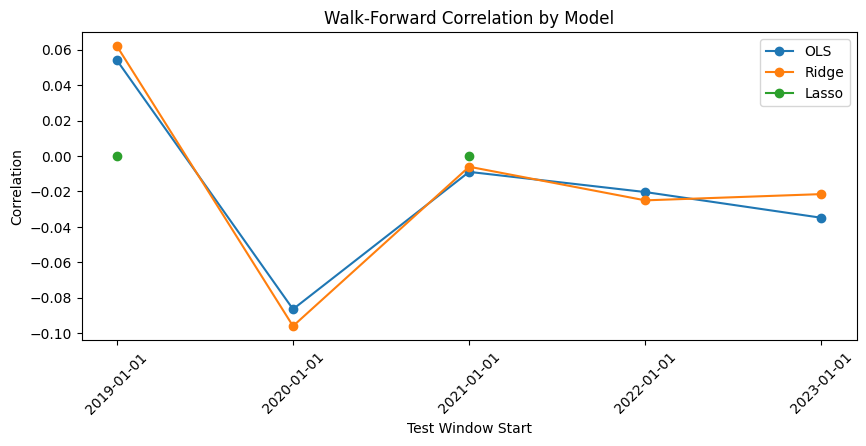

In [50]:
# Plot walk-forward correlations for all 3 models across test windows
plt.figure(figsize=(10, 4))
plt.plot(wf_results_df["Test_Start"], wf_results_df["OLS_Correlation"], marker="o", label="OLS")
plt.plot(wf_results_df["Test_Start"], wf_results_df["Ridge_Correlation"], marker="o", label="Ridge")
plt.plot(wf_results_df["Test_Start"], wf_results_df["Lasso_Correlation"], marker="o", label="Lasso")
plt.title("Walk-Forward Correlation by Model")
plt.xlabel("Test Window Start")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Results Analysis

We summarize walk-forward validation performance across models and test periods.

In [51]:
# compact summary of walk-forward validation results
print("Walk-forward results by window")
print(wf_results_df[["Test_Start", "Test_End", "OLS_Correlation", "Ridge_Correlation", "Lasso_Correlation"]])
print()

print("Average walk-forward correlation")
print(average_wf_results)

Walk-forward results by window
   Test_Start    Test_End  OLS_Correlation  Ridge_Correlation  \
0  2019-01-01  2019-12-31         0.054042           0.062038   
1  2020-01-01  2020-12-31        -0.086558          -0.096093   
2  2021-01-01  2021-12-31        -0.009003          -0.006107   
3  2022-01-01  2022-12-31        -0.020406          -0.025096   
4  2023-01-01  2023-12-31        -0.034930          -0.021563   

   Lasso_Correlation  
0      -1.420088e-16  
1                NaN  
2      -1.929935e-16  
3                NaN  
4                NaN  

Average walk-forward correlation
   Model  Average_Correlation
0    OLS        -1.937119e-02
1  Ridge        -1.736405e-02
2  Lasso        -1.675011e-16


##  Interpretation of Results

### Results show that predictive correlations between lagged returns and next-day returns remain weak across models. 
### Ridge regression slightly outperformed OLS, suggesting that mild regularization helps stabilize weak signals, while Lasso removed most predictive structure.

### Including rolling volatility did not materially improve predictive performance, suggesting that volatility alone is not sufficient to enhance short-term return predictability in this setting.

### Walk-forward validation revealed that correlations varied substantially across time windows, indicating that the signal is unstable and regime-dependent.

### Overall, results confirm that short-term equity returns are noisy and difficult to predict using simple lag-based features.

##  Limitations

  ### This study has several limitations worth acknowledging. The analysis focuses on a single asset, which limits the generalizability of any observed signal. Feature engineering was kept intentionally simple — lagged returns and rolling volatility — as the goal was hypothesis testing rather than performance optimization. No hyperparameter tuning was performed, and market regimes were not explicitly modeled, which means the results may mask structural breaks in the signal over time. Finally, only linear models were considered, leaving open the question of whether nonlinear approaches would capture additional structure. Future work could extend this framework to multi-asset datasets and explore regime-aware or nonlinear modeling approaches.


##  Conclusion
### This project explored whether simple lag-based financial features contain predictive information about next-day returns.

### Although weak correlations were detected in certain periods, results remained unstable and economically limited across time. Regularized linear models slightly improved robustness, but overall predictive power stayed low.

### The study highlights the difficulty of forecasting short-term equity returns using simple linear time-series features and emphasizes the importance of robust validation procedures in financial machine learning.
